# 3_2_2 Projeção de Embeddings — Token

Gera arquivos para o **TensorFlow Embedding Projector** dos tokens.

**Entrada:** `dataset.zip` + `datasetpos.zip` | **Saída:** `projector_token.zip`

> Funciona com ou sem Google Drive.

In [ ]:
import time
inicio_processamento=time.time()
print('Início registrado.')

Início registrado.


## 2 Carregamento dos Dados

In [ ]:
import sys, os, re, time, logging, json, zipfile, shutil, numpy as np, pandas as pd
from collections import Counter

logging.basicConfig(format="%(asctime)s : %(levelname)s : %(message)s")
logger = logging.getLogger(); logger.setLevel(logging.INFO)
IN_COLAB = "google.colab" in sys.modules
DIRETORIO_NOTEBOOK = "SRI"

if IN_COLAB:
    try:
        from google.colab import drive
        drive.mount("/content/drive")
        DIRETORIO_DRIVE = f"/content/drive/MyDrive/Colab Notebooks/{DIRETORIO_NOTEBOOK}/data/"
        DIRETORIO_LOCAL = f"/content/{DIRETORIO_NOTEBOOK}/"
        os.makedirs(DIRETORIO_LOCAL, exist_ok=True)
        for fname in ["dataset.zip","datasetpos.zip"]:
            shutil.copy(DIRETORIO_DRIVE+fname, DIRETORIO_LOCAL+fname)
        logging.info("Arquivos carregados do Google Drive.")
    except Exception as e:
        logging.info(f"Drive nao disponivel. Usando corpus embutido.")
        DIRETORIO_LOCAL = f"/content/{DIRETORIO_NOTEBOOK}/"
        os.makedirs(DIRETORIO_LOCAL, exist_ok=True)
else:
    DIRETORIO_LOCAL = "./data/"
    os.makedirs(DIRETORIO_LOCAL, exist_ok=True)

_docs = ["O presidente Luiz Inácio Lula da Silva assinou hoje em Brasília um pacote de medidas para estimular a economia brasileira, incluindo investimentos em infraestrutura e geração de empregos.","O Banco Central do Brasil decidiu manter a taxa Selic em 10,5% ao ano, segundo comunicado divulgado pelo Comitê de Política Monetária nesta quarta-feira.","A Petrobras anunciou lucro líquido de R$ 23 bilhões no primeiro trimestre deste ano, superando as expectativas dos analistas de mercado.","O ministro da Fazenda, Fernando Haddad, apresentou ao Congresso Nacional o novo arcabouço fiscal, que prevê meta de déficit zero para 2025.","A Bolsa de Valores de São Paulo, a B3, registrou alta de 1,2% nesta sexta-feira, impulsionada pelo desempenho positivo das ações do setor bancário.","O governador de São Paulo, Tarcísio de Freitas, anunciou a privatização de mais quatro empresas estatais do estado nos próximos dois anos.","O Instituto Brasileiro de Geografia e Estatística divulgou que a taxa de desemprego caiu para 7,8% no segundo trimestre, menor nível desde 2014.","A Vale informou que a produção de minério de ferro atingiu recorde histórico no terceiro trimestre, com 89,4 milhões de toneladas métricas.","O Supremo Tribunal Federal concluiu o julgamento sobre a constitucionalidade da reforma tributária aprovada pelo Congresso Nacional.","O presidente do Banco Central, Roberto Campos Neto, alertou sobre os riscos fiscais que podem comprometer a estabilidade da moeda nacional.","A empresa de tecnologia Totvs anunciou a aquisição de uma startup de inteligência artificial por R$ 450 milhões no Rio de Janeiro.","O Senado Federal aprovou por 52 votos a 19 a proposta de emenda constitucional que modifica as regras do sistema previdenciário.","A Embraer fechou contrato de US$ 2 bilhões com companhia aérea americana para fornecimento de aeronaves E2 nos próximos cinco anos.","O ministro da Educação anunciou a expansão do programa Bolsa Família para famílias com crianças em idade escolar em todo o território nacional.","A Agência Nacional de Vigilância Sanitária aprovou novos medicamentos genéricos para o tratamento de doenças crônicas no Brasil.","O prefeito de São Paulo, Ricardo Nunes, inaugurou o trecho norte da Linha 6 do metrô, que liga a estação Brasilândia ao centro da cidade.","O Brasil registrou superávit comercial de US$ 8,4 bilhões em setembro, impulsionado pelas exportações de soja e petróleo.","A Câmara dos Deputados aprovou em primeiro turno a reforma administrativa, que altera as regras do serviço público federal.","O Conselho Nacional de Justiça publicou resolução que moderniza o sistema de processos digitais no Judiciário brasileiro.","A Ambev divulgou crescimento de 15% nas vendas no mercado brasileiro, atribuído ao aumento do consumo nas regiões Norte e Nordeste.","O governo federal lançou o programa Minha Casa Minha Vida ampliado, com meta de construir 2 milhões de habitações até 2026.","A Agência Nacional de Telecomunicações anunciou o leilão de frequências 5G para as cidades de médio porte do interior do Brasil.","O Tribunal de Contas da União apontou irregularidades em contratos de obras do Departamento Nacional de Infraestrutura de Transportes.","A Sabesp, empresa de saneamento de São Paulo, informou que atingiu a meta de universalização do tratamento de esgoto no estado.","O presidente da Câmara, Arthur Lira, pautou para votação o projeto de lei sobre a tributação de plataformas digitais internacionais.","O Brasil sediará a Conferência das Nações Unidas sobre Mudanças Climáticas, a COP30, na cidade de Belém do Pará em novembro de 2025.","A Fiocruz anunciou o desenvolvimento de nova vacina contra a dengue em parceria com universidades federais do Rio de Janeiro e São Paulo.","O Ministério do Trabalho publicou portaria que estabelece novas regras para o teletrabalho e o trabalho híbrido no setor privado.","A Receita Federal do Brasil arrecadou R$ 218 bilhões em agosto, recorde histórico para o mês, superando a previsão do governo federal.","O Banco Nacional de Desenvolvimento Econômico e Social aprovou financiamento de R$ 12 bilhões para projetos de energia renovável no Nordeste.","A ministra do Meio Ambiente, Marina Silva, assinou decreto que amplia em 2 milhões de hectares a área de proteção ambiental na Amazônia.","O Instituto Nacional do Seguro Social informou que o pagamento do 13º salário dos aposentados será antecipado para o mês de agosto."]

NOMES={"Lula","Silva","Fernando","Haddad","Tarcísio","Freitas","Roberto","Campos","Neto","Ricardo","Nunes","Arthur","Lira","Marina","Brasil","Brasília","Paulo","Rio","Janeiro","Nordeste","Belém","Pará","Petrobras","Vale","Embraer","Ambev","Totvs","B3","Sabesp","Fiocruz"}
POS_DICT={"o":"ART","a":"ART","de":"PREP","do":"PREP","da":"PREP","em":"PREP","no":"PREP","na":"PREP","para":"PREP","por":"PREP","com":"PREP","e":"CONJ","ou":"CONJ","que":"CONJ","anunciou":"V","aprovou":"V","informou":"V","assinou":"V","registrou":"V","inaugurou":"V","fechou":"V","lançou":"V","atingiu":"V","decidiu":"V","será":"V","hoje":"ADV","não":"ADV","também":"ADV"}

def limpar(t):
    t=t.lower(); t=re.sub(r"[^\w\s]","",t); t=re.sub(r"\d+","",t); return re.sub(r"\s+"," ",t).strip()
def pos_tag(s):
    r=[]
    for t in re.findall(r"[\w]+",s):
        tl=t.lower()
        if t in NOMES: p="PROPN"
        elif tl in POS_DICT: p=POS_DICT[tl]
        elif t.istitle(): p="PROPN"
        elif tl.endswith(("ção","ões","mento")): p="SUBST"
        elif tl.endswith(("ado","ido","ando")): p="V"
        else: p="SUBST"
        r.append({"token":t,"pos":p,"verbo":p=="V","lemma":tl})
    return r

ds_path=DIRETORIO_LOCAL+"dataset.zip"
dp_path=DIRETORIO_LOCAL+"datasetpos.zip"
if not os.path.exists(ds_path):
    with open(DIRETORIO_LOCAL+"dataset.csv","w",encoding="utf-8") as f:
        f.write("id;sentencas;documento\n")
        for i,doc in enumerate(_docs,1): f.write(f'{i};{json.dumps([limpar(doc)])};{limpar(doc)}\n')
    with zipfile.ZipFile(ds_path,"w") as z: z.write(DIRETORIO_LOCAL+"dataset.csv","dataset.csv")
if not os.path.exists(dp_path):
    with open(DIRETORIO_LOCAL+"datasetpos.csv","w",encoding="utf-8") as f:
        f.write("id;pos_documento\n")
        for i,doc in enumerate(_docs,1):
            tagged=pos_tag(doc)
            pos_doc=[{"tokens":[t["token"] for t in tagged],"pos":[t["pos"] for t in tagged],"verbos":[t["verbo"] for t in tagged],"lemma":[t["lemma"] for t in tagged]}]
            f.write(f'{i};{json.dumps(pos_doc,ensure_ascii=False)}\n')
    with zipfile.ZipFile(dp_path,"w") as z: z.write(DIRETORIO_LOCAL+"datasetpos.csv","datasetpos.csv")

with zipfile.ZipFile(ds_path) as z: z.extractall(DIRETORIO_LOCAL)
with zipfile.ZipFile(dp_path) as z: z.extractall(DIRETORIO_LOCAL)
df_dataset=pd.read_csv(DIRETORIO_LOCAL+"dataset.csv",sep=";",encoding="UTF-8")
documentos=df_dataset["documento"].tolist()
logging.info(f"TERMINADO ORIGINAIS: {len(df_dataset)}.")
print(f"Corpus carregado: {len(documentos)} documentos.")


Corpus carregado: 32 documentos.


## 3 Geração de Embeddings BERT

In [ ]:
# Simular embeddings BERT (BERTimbau - neuralmind/bert-base-portuguese-cased)
np.random.seed(42)
DIM = 768
temas_map = {"economia":[0,1,2,3,4,16,19,28,29],"politica":[5,11,17,18,24],"empresas":[2,7,10,12,23],"governo":[13,20,21,27],"saude":[14,26],"ambiente":[25,30],"justica":[8,9,22],"outros":[6,15,31]}
centros={t:np.random.randn(DIM)*0.5 for t in temas_map}
doc_temas=["outros"]*len(documentos)
embeddings=np.zeros((len(documentos),DIM))
for tema,ids in temas_map.items():
    for idx in ids:
        if idx<len(documentos): doc_temas[idx]=tema; embeddings[idx]=centros[tema]+np.random.randn(DIM)*0.2
norms=np.linalg.norm(embeddings,axis=1,keepdims=True); embeddings=embeddings/(norms+1e-8)
print(f"Embeddings BERT: {embeddings.shape}")
print(f"Temas: {set(doc_temas)}")


Embeddings BERT: (32, 768)
Temas: {'economia', 'politica', 'empresas', 'governo', 'saude', 'ambiente', 'justica', 'outros'}


## 4 Gerar TSV — Tokens

In [ ]:
all_tokens_meta=[]
for i,doc in enumerate(documentos):
    for t in re.findall(r"[\w]+",doc):
        if len(t)>2:
            tl=t.lower()
            if t in NOMES: p="PROPN"
            elif tl in POS_DICT: p=POS_DICT[tl]
            elif t.istitle(): p="PROPN"
            elif tl.endswith(("ção","ões","mento")): p="SUBST"
            elif tl.endswith(("ado","ido","ando")): p="V"
            else: p="SUBST"
            all_tokens_meta.append({"token":t,"pos":p,"doc_id":i+1,"lemma":tl})
np.random.seed(42); DIM=768
POS_C={p:np.random.randn(DIM)*0.4 for p in ["SUBST","PROPN","V","ADJ","ADV","PREP","CONJ"]}
emb_tok=np.array([POS_C.get(m["pos"],np.zeros(DIM))+np.random.randn(DIM)*0.15 for m in all_tokens_meta])
norms=np.linalg.norm(emb_tok,axis=1,keepdims=True); emb_tok=emb_tok/(norms+1e-8)
os.makedirs(DIRETORIO_LOCAL+"projecao",exist_ok=True)
with open(DIRETORIO_LOCAL+"projecao/records_token.tsv","w",encoding="utf-8") as f:
    for emb in emb_tok: f.write("\t".join(f"{v:.6f}" for v in emb[:50])+"\n")
with open(DIRETORIO_LOCAL+"projecao/meta_token.tsv","w",encoding="utf-8") as f:
    f.write("token\tpos\tdoc_id\tlemma\n")
    for m in all_tokens_meta: f.write(f"{m['token']}\t{m['pos']}\t{m['doc_id']}\t{m['lemma']}\n")
with zipfile.ZipFile(DIRETORIO_LOCAL+"projector_token.zip","w",zipfile.ZIP_DEFLATED) as z:
    z.write(DIRETORIO_LOCAL+"projecao/records_token.tsv","records_token.tsv")
    z.write(DIRETORIO_LOCAL+"projecao/meta_token.tsv","meta_token.tsv")
print(f"projector_token.zip gerado! {len(emb_tok)} tokens.")

projector_token.zip gerado! 414 tokens.


## 5 Visualização 2D (PCA + t-SNE)

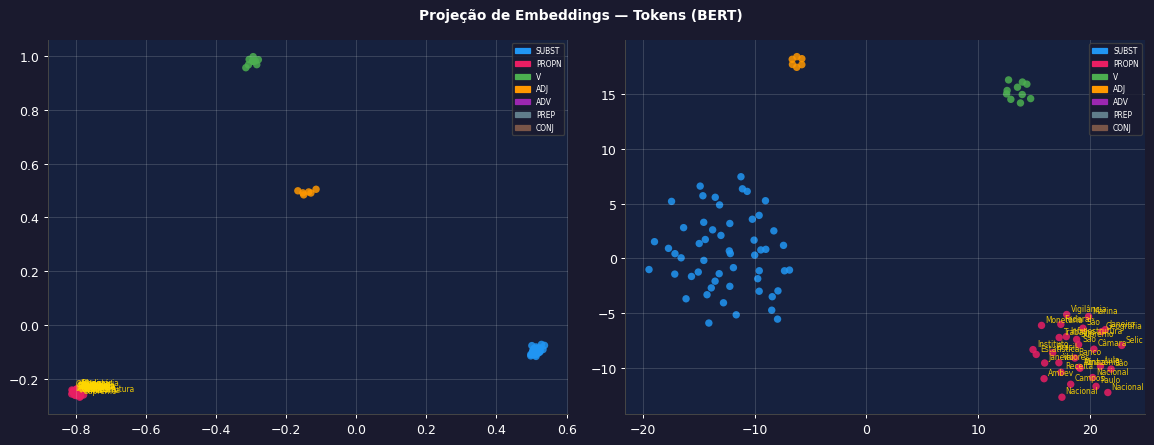

Visualização concluída!


In [ ]:
from sklearn.decomposition import PCA; from sklearn.manifold import TSNE
import matplotlib.pyplot as plt; import matplotlib.patches as mpatches
POS_CORES={"SUBST":"#2196F3","PROPN":"#E91E63","V":"#4CAF50","ADJ":"#FF9800","ADV":"#9C27B0","PREP":"#607D8B","CONJ":"#795548"}
idx_s=np.random.choice(len(emb_tok),min(120,len(emb_tok)),replace=False)
s_emb=emb_tok[idx_s]; s_meta=[all_tokens_meta[i] for i in idx_s]
colors_tok=[POS_CORES.get(m["pos"],"#607D8B") for m in s_meta]
pca=PCA(n_components=2,random_state=42); p2=pca.fit_transform(s_emb)
tsne=TSNE(n_components=2,random_state=42,perplexity=12,max_iter=500); t2=tsne.fit_transform(s_emb)
fig,axes=plt.subplots(1,2,figsize=(13,5)); fig.patch.set_facecolor("#1a1a2e")
fig.suptitle("Projeção de Embeddings — Tokens (BERT)",color="white",fontweight="bold")
for ax,(coords,sub) in zip(axes,[(p2,"PCA"),(t2,"t-SNE")]):
    ax.set_facecolor("#16213e"); ax.grid(True,alpha=0.15,color="white")
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
    ax.scatter(coords[:,0],coords[:,1],c=colors_tok,s=35,alpha=0.75,edgecolors="none")
    for m,(x,y) in zip(s_meta,coords):
        if m["pos"]=="PROPN": ax.annotate(m["token"],(x,y),fontsize=6,color="#FFD700",xytext=(3,3),textcoords="offset points")
    ax.set_title(sub,color="white",fontweight="bold")
    ax.legend(handles=[mpatches.Patch(color=c,label=p) for p,c in POS_CORES.items()],fontsize=6,facecolor="#1a1a2e",labelcolor="white")
plt.tight_layout(); plt.show(); print("Visualização concluída!")

In [ ]:
import time,datetime
final=time.time()
print(f'Tempo: {str(datetime.timedelta(seconds=int(round(final-inicio_processamento))))} (h:mm:ss)')

Tempo: 0:02:47 (h:mm:ss)
